In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anastruct as ast

np.set_printoptions(suppress=True, precision=3)

In [243]:
class Viga():

    def __init__(self, i):
        self.i = i
        self.loads = {}

In [244]:
L_x = [6,7,7,6] # m
h_z = [4,3,3,3,3,3] # m
at = 6 # m

In [245]:
fc = 280 # kg/cm²
Ec = 15000 * fc**0.5 * 10 # ton/m²

c_b = 0.5
c_h = 0.5
v_b = 0.3
v_h = 0.6

A_c = c_b * c_h
I_c = c_b * c_h**3 / 12
A_v = v_b * v_h
I_v = v_b * v_h**3 / 12

In [246]:
ejes_x = [0]
for x in L_x: ejes_x.append(ejes_x[-1]+x)

ejes_z = [0]
for z in h_z: ejes_z.append(ejes_z[-1]+z)
print(ejes_x)
print(ejes_z)

[0, 6, 13, 20, 26]
[0, 4, 7, 10, 13, 16, 19]


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
[31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]


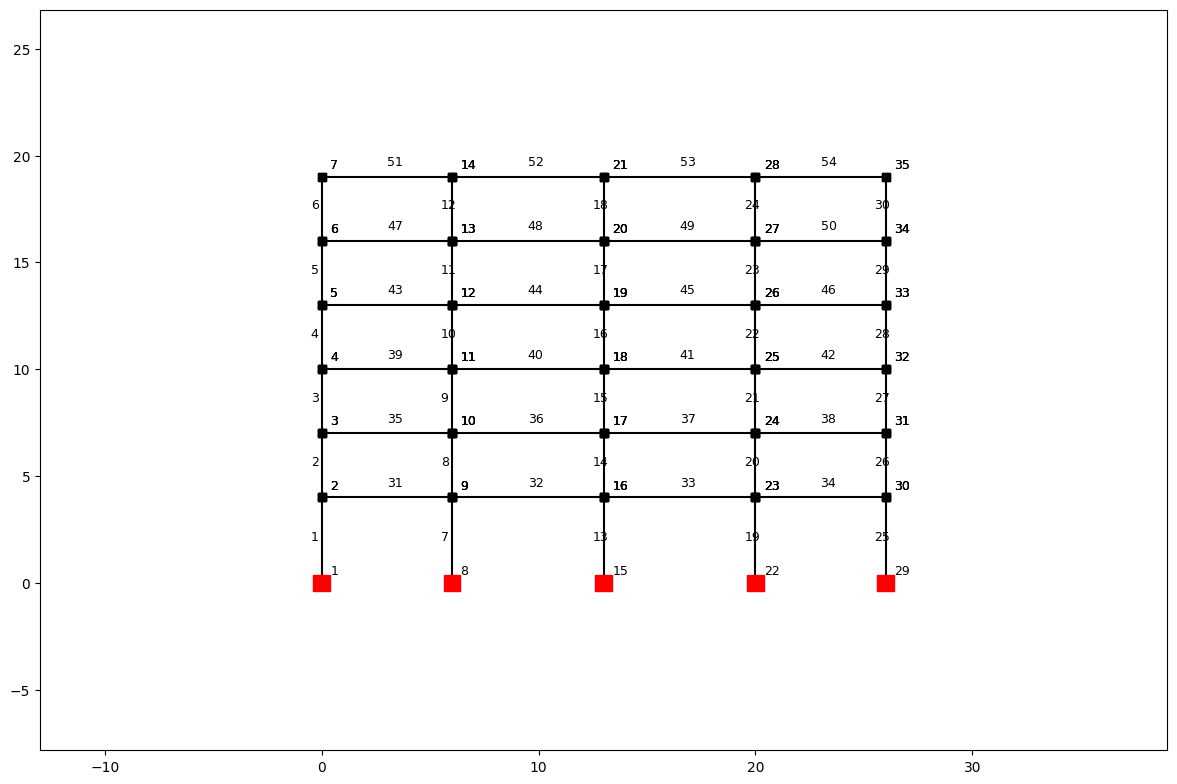

In [247]:
ss = ast.SystemElements()

k = 0

id_columnas = []
# modelamiento de columnas
for i in range(len(ejes_x)):
    for j in range(len(h_z)):
        ss.add_element([[ejes_x[i],ejes_z[j]],[ejes_x[i],ejes_z[j+1]]], EA = Ec*A_c, EI = Ec*I_c)
        k += 1
        id_columnas.append(k)

id_vigas = []
# modelamiento de vigas
for i in range(len(h_z)):
    for j in range(len(L_x)):
        ss.add_element([[ejes_x[j],ejes_z[i+1]],[ejes_x[j+1],ejes_z[i+1]]], EA = Ec*A_v, EI = Ec*I_v)
        k += 1
        id_vigas.append(k)

# Asignación de apoyos empotrados

for x in ejes_x:
    ss.add_support_fixed(node_id=ss.find_node_id((x,0)))
    pass

print(id_columnas)
print(id_vigas)

ss.show_structure()

{'D': {'length': 6.0, 'Q': array([ 15.666,  15.003,  14.341,  13.678,  13.016,  12.353,  11.691,
        11.029,  10.366,   9.704,   9.041,   8.379,   7.716,   7.054,
         6.391,   5.729,   5.067,   4.404,   3.742,   3.079,   2.417,
         1.754,   1.092,   0.429,  -0.233,  -0.895,  -1.558,  -2.22 ,
        -2.883,  -3.545,  -4.208,  -4.87 ,  -5.533,  -6.195,  -6.858,
        -7.52 ,  -8.182,  -8.845,  -9.507, -10.17 , -10.832, -11.495,
       -12.157, -12.82 , -13.482, -14.144, -14.807, -15.469, -16.132,
       -16.794]), 'M': array([-13.919, -12.042, -10.245,  -8.529,  -6.895,  -5.342,  -3.87 ,
        -2.479,  -1.169,   0.06 ,   1.208,   2.274,   3.259,   4.164,
         4.987,   5.729,   6.39 ,   6.97 ,   7.469,   7.886,   8.223,
         8.478,   8.652,   8.745,   8.757,   8.688,   8.538,   8.307,
         7.994,   7.601,   7.126,   6.57 ,   5.933,   5.215,   4.416,
         3.536,   2.575,   1.532,   0.409,  -0.796,  -2.082,  -3.449,
        -4.897,  -6.426,  -8.037,  -9.72

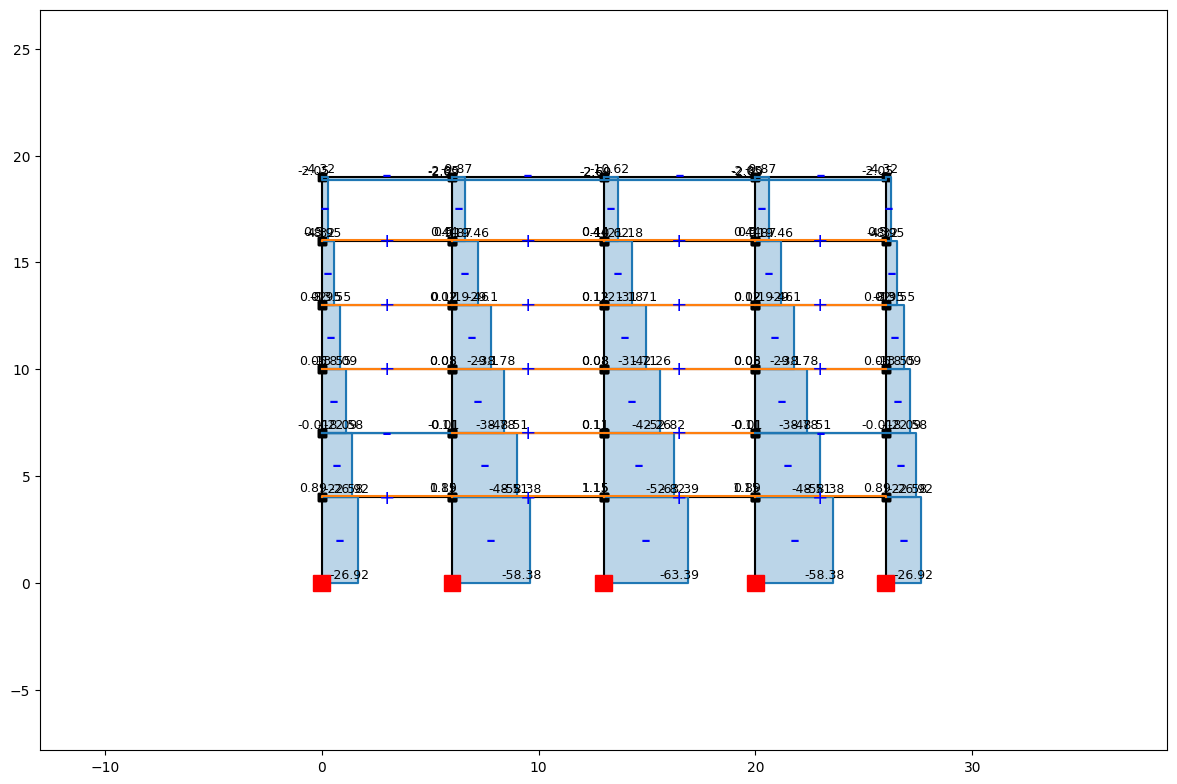

'\nE = [100, 130, 150,180,200,230]\nfor i in range(len(h_z)):\n    for j in range(len(ejes_x)):\n        lc_E.point_load(Fx=round(E[i]/len(ejes_x),1), node_id=2+j*len(ejes_z)+i)\n'

In [248]:
# Asignación de cargas

# Load Case Dead
w1 = 2.4 * 0.2 * at # Peso propio de la losa, ton/m
w2 = 2.4 * A_v # Peso propio de la viga, ton/m
w3 = at * (0.100 + 0.250) # acabados + tabiquería, ton/m
lc_D = ast.LoadCase("Dead")
for viga in id_vigas:
    lc_D.q_load(q = -round(w1+w2+w3,2), element_id=viga, direction="y")
for col in id_columnas:
    lc_D.q_load(q = -A_c*2.4, element_id=col, direction="y")


# Load Case Live
l1 = 0.250 * at # Peso propio de la losa, ton/m
lc_L = ast.LoadCase("Live")
for viga in id_vigas:
    lc_L.q_load(q = -round(l1,2), element_id=viga)#, direction="y")

vigas = {}

# Aplicación de cargas y guardado de fuerzas

ss.apply_load_case(lc_D)
ss.solve()

for v in id_vigas:
    res = ss.get_element_results(element_id=v, verbose=True)
    #print(res.keys())
    filtro = ["length", "M", "Q", "N"]
    vigas[v] = Viga(v)
    vigas[v].loads["D"] = {"length": res["length"], "Q": -res["Q"], "M": -res["M"], "N": -res["N"]}
    #print(vigas[v].loads)

ss.remove_loads()
ss.apply_load_case(lc_L)
ss.solve()

for v in id_vigas:
    res = ss.get_element_results(element_id=v, verbose=True)
    #print(res.keys())
    filtro = ["length", "M", "Q", "N"]
    vigas[v].loads["L"] = {"length": res["length"], "Q": -res["Q"], "M": -res["M"], "N": -res["N"]}
    print(vigas[v].loads)



ss.show_axial_force()



# Load Case EarthQuake
lc_E = ast.LoadCase("EarthQuake")
"""
E = [100, 130, 150,180,200,230]
for i in range(len(h_z)):
    for j in range(len(ejes_x)):
        lc_E.point_load(Fx=round(E[i]/len(ejes_x),1), node_id=2+j*len(ejes_z)+i)
"""
        


In [249]:
Comb0 = ast.LoadCombination("ComboMasa")
Comb0.add_load_case(lc_D, 1.0)
Comb0.add_load_case(lc_L, 1.0)

Comb1 = ast.LoadCombination("Combo 1")
Comb1.add_load_case(lc_D, 1.4)
Comb1.add_load_case(lc_L, 1.7)

Comb2 = ast.LoadCombination("Combo 2")
Comb2.add_load_case(lc_D, 1.25)
Comb2.add_load_case(lc_L, 1.25)
Comb2.add_load_case(lc_E, 1)

Comb3 = ast.LoadCombination("Combo 3")
Comb3.add_load_case(lc_D, 1.25)
Comb3.add_load_case(lc_L, 1.25)
Comb3.add_load_case(lc_E, -1)

Comb4 = ast.LoadCombination("Combo 4")
Comb4.add_load_case(lc_D, 0.90)
Comb4.add_load_case(lc_E, 1)

Comb5 = ast.LoadCombination("Combo 5")
Comb5.add_load_case(lc_D, 0.90)
Comb5.add_load_case(lc_E, -1)

In [250]:
# Cálculo de masa por piso
ss.remove_loads()
r = Comb0.solve(ss)
s_masa = r["combination"]
pesos = []
for i in range(1,len(h_z)+1):
    pesos.append(0)
    for j in range(len(ejes_x)):
        #print(i+j*len(h_z))
        res = s_masa.get_element_results(element_id=i+j*len(h_z), verbose=True)
        N = -res["N"][int(len(res["N"])/2)]
        pesos[-1] += N
        #print(N)
        #print(pesos)
# print(pesos)
for i in range(len(h_z)-1):
    pesos[i] = pesos[i] - pesos[i+1]

# print(pesos)

ss.remove_loads()

# Cálculo de rigidez
# Para este procedimiento se calculará una matriz de flexibilidad
u_matrix = []
for i in range(len(h_z)):
    ss.point_load(node_id=i+2, Fx=1000)
    #ss.show_structure(scale=0.7)
    ss.solve()
    #ss.show_displacement()
    u_matrix.append([])
    for k in range(2,len(h_z)+2):
        temp = ss.get_node_displacements(k)["ux"]
        # print("Temp",k,temp)
        u_matrix[-1].append(temp)
    #ss.show_structure()
    ss.remove_loads()
u_matrix = np.array(u_matrix).T
# print(u_matrix)
k_matrix = np.linalg.inv(u_matrix)/1000
print(k_matrix)

rigideces = []
for i in range(len(h_z)-1):
    rigideces.append(k_matrix[i,i]+k_matrix[i,i+1])
rigideces.append(k_matrix[-1,-1])

print(rigideces)

[[ 0.021 -0.013  0.001 -0.     0.     0.   ]
 [-0.013  0.023 -0.013  0.002 -0.     0.   ]
 [ 0.001 -0.013  0.024 -0.013  0.001 -0.   ]
 [-0.     0.002 -0.013  0.024 -0.013  0.001]
 [ 0.    -0.     0.001 -0.013  0.022 -0.011]
 [ 0.     0.    -0.     0.001 -0.011  0.01 ]]
[np.float64(0.00786656083075707), np.float64(0.010301561817616255), np.float64(0.010417238010392316), np.float64(0.010550335649919541), np.float64(0.011636237835679797), np.float64(0.009504957274143848)]


In [251]:
for x in ejes_x:
    print(ss.get_node_results_system(ss.find_node_id([x,0])))

rr = ss.get_element_results(element_id=5, verbose=True)
filtro = ["id", "length", "M"]
filtrado = {k: rr[k] for k in filtro}
filtrado

{'id': 1, 'Fx': np.float64(176.85962487552848), 'Fy': np.float64(760.0233565219372), 'Tz': np.float64(-470.46087684334793), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
{'id': 8, 'Fx': np.float64(217.8602313130922), 'Fy': np.float64(-218.37026218305832), 'Tz': np.float64(-526.0476775658553), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
{'id': 15, 'Fx': np.float64(210.42269754433343), 'Fy': np.float64(-6.710658769579928), 'Tz': np.float64(-516.3772046051508), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
{'id': 22, 'Fx': np.float64(217.9166893164731), 'Fy': np.float64(197.40652359881923), 'Tz': np.float64(-526.1309655601599), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
{'id': 29, 'Fx': np.float64(176.94075695057293), 'Fy': np.float64(-732.3489591681193), 'Tz': np.float64(-470.5806719282321), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}


{'id': 5,
 'length': 3.0,
 'M': array([ 199.792,  191.781,  183.77 ,  175.758,  167.747,  159.736,
         151.725,  143.713,  135.702,  127.691,  119.68 ,  111.668,
         103.657,   95.646,   87.634,   79.623,   71.612,   63.601,
          55.589,   47.578,   39.567,   31.556,   23.544,   15.533,
           7.522,   -0.49 ,   -8.501,  -16.512,  -24.523,  -32.535,
         -40.546,  -48.557,  -56.568,  -64.58 ,  -72.591,  -80.602,
         -88.614,  -96.625, -104.636, -112.647, -120.659, -128.67 ,
        -136.681, -144.692, -152.704, -160.715, -168.726, -176.738,
        -184.749, -192.76 ])}

### Flujo de diseño

1. Se determina la geometría de secciones y de la estructura

2. Se modela elementos usando anastruct

3. Se generan los casos de carga Dead y Live

4. Se calcula la masa sísmica de cada piso

5. Se calcula las rigideces por piso mediante la matriz de flexibilidad aplicando cargas laterales unitarias por piso

6. Se realiza en análisis sísmico para obtener la fuerzas sísmicas en cada piso (puede ser estático o espectral)

7. Se crea el caso de carga EarthQuake

8. Se generan los combos de diseño C1, C2, C3, C4 y C5

9. Se obtiene la envolvente de momentos flectores para el diseño a flexión de las vigas

10. Se genera combo 1.25 D + 1.25 L para el diseño por capacidad a corte de las vigas

11. Se genera reporte automático de análisis sísmico y diseño de vigas